In [1]:
!pip install hmmlearn cvxpy yfinance pandas numpy scipy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [3]:
tickers = ["SPY", "IEF", "TLT", "GLD", "QQQ", "EFA", "EEM", "LQD", "HYG", "UUP"]
start_date = "2015-01-01"
end_date = "2024-12-31"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

prices = data["Adj Close"].dropna(how="all")
prices.head()

Ticker,EEM,EFA,GLD,HYG,IEF,LQD,QQQ,SPY,TLT,UUP
Date,,,,,,,,,,
2015-01-02,30.355053,43.780636,114.080002,49.046158,82.868385,80.710693,94.665077,170.125000,93.367287,20.216694
2015-01-05,29.814812,42.747177,115.800003,48.591820,83.374039,81.040726,93.276459,167.052612,94.833931,20.258465
2015-01-06,29.689543,42.262970,117.120003,48.405716,83.934128,81.370728,92.025772,165.479111,96.542618,20.300234
2015-01-07,30.331564,42.732735,116.430000,48.706772,83.918518,81.478577,93.212074,167.541229,96.351936,20.375420
2015-01-08,30.848314,43.310879,115.940002,49.073574,83.576279,81.215836,94.996124,170.514267,95.075974,20.458960


In [4]:
returns = prices.pct_change().dropna()

mkt = returns.mean(axis=1)
features = pd.DataFrame(index=returns.index)
features["mkt_ret"] = mkt
features["vol"] = mkt.rolling(20).std()
features["skew"] = mkt.rolling(20).skew()
features["kurt"] = mkt.rolling(20).kurt()
features["sharpe"] = mkt.rolling(20).mean() / mkt.rolling(20).std() * np.sqrt(252)
features["mom_1m"] = mkt.rolling(21).sum()
features["mom_3m"] = mkt.rolling(63).sum()
features = features.dropna()

common_idx = returns.index.intersection(features.index)
returns = returns.loc[common_idx]
features = features.loc[common_idx]

returns.head(), features.head()

(Ticker           EEM       EFA       GLD       HYG       IEF       LQD  \
 Date                                                                     
 2015-04-06  0.012851  0.010124  0.012231  0.002543  0.001291  0.001316   
 2015-04-07 -0.005028 -0.001367 -0.004970  0.005293  0.000829  0.003615   
 2015-04-08  0.020934  0.004258 -0.005512 -0.000219 -0.000920 -0.000327   
 2015-04-09  0.009898  0.001363 -0.006928 -0.000988 -0.004053 -0.005078   
 2015-04-10  0.000701  0.001966  0.011337  0.002306 -0.000278  0.001400   
 
 Ticker           QQQ       SPY       TLT       UUP  
 Date                                                
 2015-04-06  0.008181  0.006733 -0.005584 -0.007779  
 2015-04-07 -0.001698 -0.002646  0.008385  0.011368  
 2015-04-08  0.007939  0.003377  0.000305  0.001551  
 2015-04-09  0.006283  0.004424 -0.012964  0.010449  
 2015-04-10  0.004100  0.005457  0.001468  0.002298  ,
              mkt_ret       vol      skew      kurt    sharpe    mom_1m  \
 Date              

In [5]:
vix = yf.download("^VIX", start=start_date, end=end_date, auto_adjust=False, progress=False)
vix = vix["Adj Close"] if "Adj Close" in vix.columns else vix["Close"]
vix = vix.reindex(features.index).ffill()

features["VIX"] = vix
features = features.dropna()

common_idx = returns.index.intersection(features.index)
returns = returns.loc[common_idx]
features = features.loc[common_idx]

features.head()

,mkt_ret,vol,skew,kurt,sharpe,mom_1m,mom_3m,VIX
Date,,,,,,,,
2015-04-06,0.004191,0.004765,0.073484,0.160249,3.988254,0.012070,0.040272,14.74
2015-04-07,0.001378,0.004760,0.100508,0.179439,3.862668,0.025322,0.045685,14.78
2015-04-08,0.003139,0.004483,0.011152,0.680537,5.685745,0.026304,0.048815,13.98
2015-04-09,0.000241,0.004489,0.089615,0.665273,5.295201,0.032355,0.042927,13.09
2015-04-10,0.003075,0.004483,0.098889,0.687351,5.251673,0.033023,0.040570,12.58


In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

hmm_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42
)

hmm_model.fit(X)
regimes = hmm_model.predict(X)
regime_probs = hmm_model.predict_proba(X)

regime_series = pd.Series(regimes, index=features.index, name="regime")
transition_matrix = hmm_model.transmat_

transition_matrix

array([[0.95140818, 0.0432182 , 0.00537362],
       [0.03525498, 0.94850901, 0.016236  ],
       [0.01633063, 0.01379374, 0.96987562]])

In [7]:
regime_names = {0: "Bull", 1: "Bear", 2: "Crisis"}

regime_summary = {}
for r in range(3):
    mask = regime_series == r
    reg_ret = returns.loc[mask].mean(axis=1)
    regime_summary[regime_names[r]] = {
        "n_days": int(mask.sum()),
        "avg_daily_ret": reg_ret.mean(),
        "daily_vol": reg_ret.std(),
        "annual_return": reg_ret.mean() * 252,
        "annual_vol": reg_ret.std() * np.sqrt(252),
        "sharpe": (reg_ret.mean() * 252) / (reg_ret.std() * np.sqrt(252))
    }

pd.DataFrame(regime_summary).T

,n_days,avg_daily_ret,daily_vol,annual_return,annual_vol,sharpe
Bull,890.0,0.000575,0.003161,0.144858,0.050186,2.886430
Bear,911.0,0.000163,0.004358,0.040970,0.069174,0.592271
Crisis,651.0,-0.000076,0.008246,-0.019046,0.130908,-0.145491


IndexError: index 948 is out of bounds for axis 0 with size 890

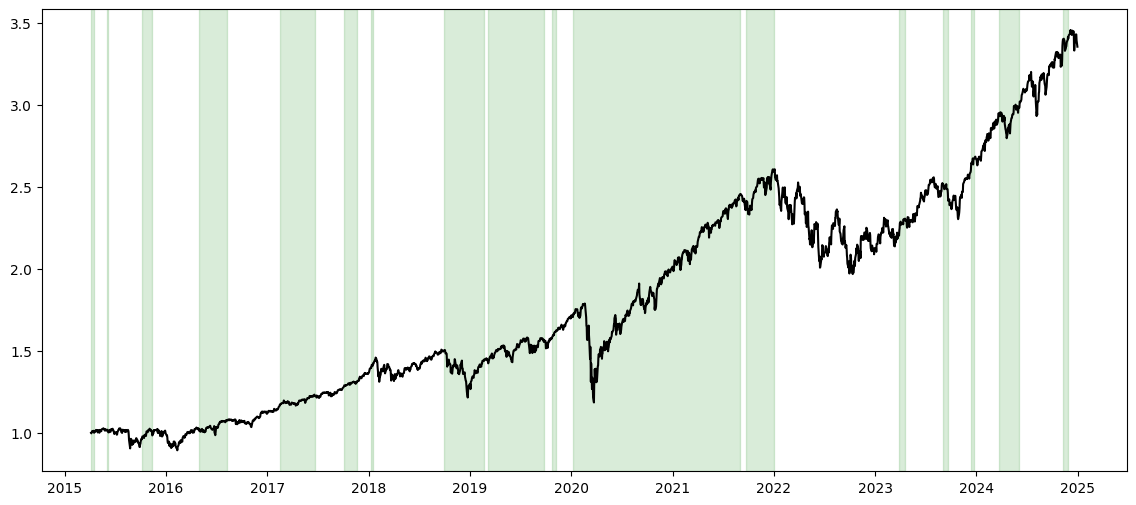

In [8]:
spy = prices.loc[features.index, "SPY"]
norm_spy = spy / spy.iloc[0]

plt.figure(figsize=(14,6))
plt.plot(norm_spy.index, norm_spy.values, color="black", linewidth=1.5)

colors = {0: "green", 1: "red", 2: "orange"}
for r in range(3):
    mask = regime_series == r
    idx = regime_series.index[mask]
    if len(idx) > 0:
        spans = np.split(np.where(mask.values)[0], np.where(np.diff(np.where(mask.values)[0]) > 1)[0] + 1)
        for s in spans:
            if len(s) > 0:
                plt.axvspan(idx[s[0]], idx[s[-1]], color=colors[r], alpha=0.15)

plt.title("SPY with HMM Regimes")
plt.legend(["SPY"])
plt.grid(alpha=0.3)
plt.show()

In [9]:
def cov_psd(df):
    cov = df.cov().values * 252
    eigval, eigvec = np.linalg.eigh(cov)
    eigval = np.maximum(eigval, 1e-8)
    return eigvec @ np.diag(eigval) @ eigvec.T

def optimize_max_sharpe(mu, cov, rf=0.02):
    n = len(mu)
    w = cp.Variable(n)
    ret = mu @ w
    vol = cp.sqrt(cp.quad_form(w, cov))
    prob = cp.Problem(cp.Maximize((ret - rf) / vol), [cp.sum(w) == 1, w >= 0, w <= 0.4])
    prob.solve(solver=cp.SCS)
    return w.value

def optimize_min_vol(cov):
    n = cov.shape[0]
    w = cp.Variable(n)
    vol = cp.sqrt(cp.quad_form(w, cov))
    prob = cp.Problem(cp.Minimize(vol), [cp.sum(w) == 1, w >= 0, w <= 0.4])
    prob.solve(solver=cp.SCS)
    return w.value

def optimize_max_return(mu, cov, vol_limit=0.15):
    n = len(mu)
    w = cp.Variable(n)
    ret = mu @ w
    vol = cp.sqrt(cp.quad_form(w, cov))
    prob = cp.Problem(cp.Maximize(ret), [cp.sum(w) == 1, w >= 0, w <= 0.4, vol <= vol_limit])
    prob.solve(solver=cp.SCS)
    return w.value

In [14]:
def cov_psd(df):
    cov = df.cov().values * 252
    eigval, eigvec = np.linalg.eigh(cov)
    eigval = np.maximum(eigval, 1e-8)
    return eigvec @ np.diag(eigval) @ eigvec.T

def optimize_max_sharpe(mu, cov, rf=0.02):
    n = len(mu)
    w = cp.Variable(n)
    ret = mu @ w
    prob = cp.Problem(
        cp.Maximize(ret - rf),
        [cp.sum(w) == 1, w >= 0, w <= 0.4]
    )
    prob.solve(solver=cp.SCS)
    return w.value

def optimize_min_vol(cov):
    n = cov.shape[0]
    w = cp.Variable(n)
    variance = cp.quad_form(w, cov)
    prob = cp.Problem(
        cp.Minimize(variance),
        [cp.sum(w) == 1, w >= 0, w <= 0.4]
    )
    prob.solve(solver=cp.SCS)
    return w.value

def optimize_max_return(mu, cov, vol_limit=0.15):
    n = len(mu)
    w = cp.Variable(n)
    ret = mu @ w
    variance = cp.quad_form(w, cov)
    prob = cp.Problem(
        cp.Maximize(ret),
        [cp.sum(w) == 1, w >= 0, w <= 0.4, variance <= vol_limit**2]
    )
    prob.solve(solver=cp.SCS)
    return w.value

In [15]:
train_window = 252
rebalance_freq = 21
tc_bps = 7.5
initial_capital = 100000

portfolio_values = [initial_capital]
portfolio_returns = []
weight_hist = []
turnover_hist = []
current_w = None

i = train_window
while i < len(returns):
    train_ret = returns.iloc[i-train_window:i]
    train_feat = features.iloc[i-train_window:i]
    test_feat = features.iloc[i:i+1]

    X_train = scaler.fit_transform(train_feat)
    hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=200, random_state=42)
    hmm_model.fit(X_train)

    reg = int(hmm_model.predict(scaler.transform(test_feat))[0])

    mu = train_ret.mean().values * 252
    cov = cov_psd(train_ret)

    if reg == 0:
        w = optimize_max_sharpe(mu, cov)
    elif reg == 1:
        w = optimize_max_return(mu, cov)
    else:
        w = optimize_min_vol(cov)

    w = pd.Series(w / np.sum(w), index=returns.columns)

    if current_w is None:
        turnover = 0.0
        tc = 0.0
    else:
        turnover = abs(w - current_w).sum() / 2
        tc = turnover * (tc_bps / 10000)

    period_rets = (returns.iloc[i:i+rebalance_freq] * w).sum(axis=1)
    net_rets = period_rets - tc
    avg_ret = net_rets.mean()

    portfolio_values.append(portfolio_values[-1] * (1 + avg_ret))
    portfolio_returns.append(avg_ret)
    weight_hist.append(w)
    turnover_hist.append(turnover)
    current_w = w.copy()

    i += rebalance_freq

portfolio_returns = pd.Series(portfolio_returns)
portfolio_values = pd.Series(portfolio_values)
weight_hist = pd.DataFrame(weight_hist)
turnover_hist = pd.Series(turnover_hist)

portfolio_returns.head()

,0
0,0.000381
1,-0.001371
2,0.001944
3,-0.000454
4,0.000288


In [18]:
def performance_stats(r, rf=0.02):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol != 0 else 0
    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else ann_vol
    sortino = (ann_ret - rf) / downside_vol if downside_vol != 0 else 0
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0
    return pd.Series({
        "annual_return": ann_ret,
        "annual_volatility": ann_vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": mdd,
        "calmar_ratio": calmar
    })

r_60_40 = 0.6 * returns["SPY"] + 0.4 * returns["IEF"]

common_idx = returns.index.intersection(portfolio_returns.index)
r_60_40 = r_60_40.loc[common_idx]
r_equal = returns.mean(axis=1).loc[common_idx]
r_dyn = portfolio_returns.loc[common_idx]

comparison = pd.DataFrame({
    "Dynamic_HMM": performance_stats(r_dyn),
    "60_40": performance_stats(r_60_40.loc[r_dyn.index]),
    "Equal_Weight": performance_stats(r_equal)
}).T

comparison

,annual_return,annual_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio
Dynamic_HMM,NaN,NaN,NaN,NaN,NaN,NaN
60_40,NaN,NaN,NaN,NaN,NaN,NaN
Equal_Weight,NaN,NaN,NaN,NaN,NaN,NaN


              annual_return  annual_volatility  sharpe_ratio  sortino_ratio  \
Dynamic_HMM       -0.005421           0.022972     -1.106619      -1.465629   
60_40             -0.098957           0.089200     -1.333596      -1.667661   
Equal_Weight      -0.148182           0.071864     -2.340285      -3.150969   

              max_drawdown  calmar_ratio  
Dynamic_HMM      -0.013909     -0.389772  
60_40            -0.069369     -1.426542  
Equal_Weight     -0.084142     -1.761099  


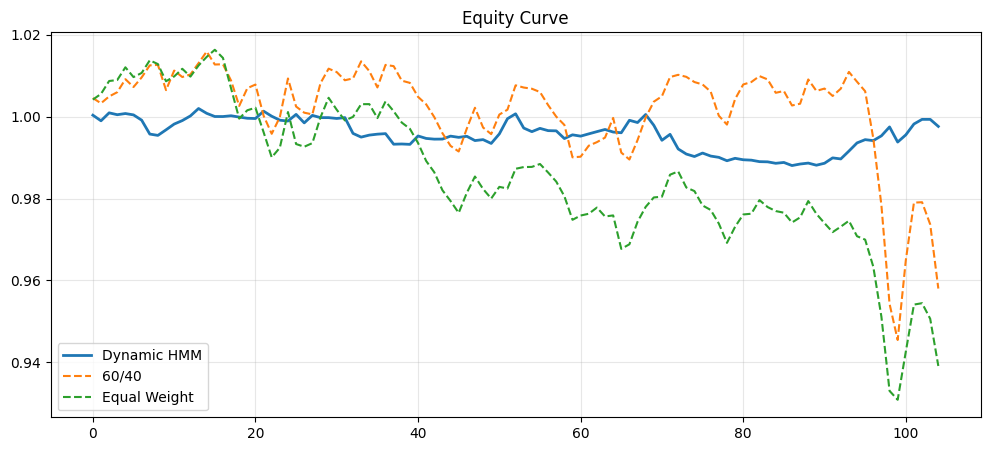

In [21]:
# Align series and remove missing values
r_60_40 = (0.6 * returns["SPY"] + 0.4 * returns["IEF"]).dropna()
r_equal = returns.mean(axis=1).dropna()

# Make sure dynamic returns is a Series
r_dyn = portfolio_returns.copy()

# If r_dyn has a RangeIndex, align by position
min_len = min(len(r_dyn), len(r_60_40), len(r_equal))
r_dyn = pd.Series(r_dyn.values[:min_len])
r_60_40 = pd.Series(r_60_40.values[:min_len])
r_equal = pd.Series(r_equal.values[:min_len])

def performance_stats(r, rf=0.02):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return pd.Series({
            "annual_return": np.nan,
            "annual_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "sortino_ratio": np.nan,
            "max_drawdown": np.nan,
            "calmar_ratio": np.nan
        })
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol != 0 else np.nan
    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else ann_vol
    sortino = (ann_ret - rf) / downside_vol if downside_vol != 0 else np.nan
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()
    calmar = ann_ret / abs(mdd) if mdd != 0 else np.nan
    return pd.Series({
        "annual_return": ann_ret,
        "annual_volatility": ann_vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": mdd,
        "calmar_ratio": calmar
    })

comparison = pd.DataFrame({
    "Dynamic_HMM": performance_stats(r_dyn),
    "60_40": performance_stats(r_60_40),
    "Equal_Weight": performance_stats(r_equal)
}).T

print(comparison)

plt.figure(figsize=(12, 5))
plt.plot((1 + r_dyn.fillna(0)).cumprod(), label="Dynamic HMM", linewidth=2)
plt.plot((1 + r_60_40.fillna(0)).cumprod(), label="60/40", linestyle="--")
plt.plot((1 + r_equal.fillna(0)).cumprod(), label="Equal Weight", linestyle="--")
plt.title("Equity Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
regime_out = pd.DataFrame({
    "regime": regime_series,
    "prob_bull": regime_probs[:, 0],
    "prob_bear": regime_probs[:, 1],
    "prob_crisis": regime_probs[:, 2]
}, index=features.index)

regime_out.to_csv("regime_labels.csv")
regime_out.head()

,regime,prob_bull,prob_bear,prob_crisis
Date,,,,
2015-04-06,0,1.000000,2.092358e-45,5.288325e-242
2015-04-07,0,0.999647,3.530319e-04,1.091092e-07
2015-04-08,0,0.999691,3.093110e-04,1.195243e-09
2015-04-09,0,0.999915,8.460583e-05,6.580219e-09
2015-04-10,0,0.999930,7.039897e-05,1.164274e-08
